In [2]:
! pip install networkx
! pip install matplotlib

node degree clustering
0 6 0.26666666666666666
1 3 0.3333333333333333
2 4 0.3333333333333333
3 5 0.3
4 2 0
5 4 0.6666666666666666
6 7 0.19047619047619047
7 4 0.3333333333333333
8 4 0.5
9 3 0
10 3 0
11 4 0
12 0 0
13 4 0.5
14 8 0.2857142857142857
15 1 0
16 4 0.5
17 6 0.26666666666666666
18 3 0.3333333333333333
19 5 0

the adjacency list
0 7 17 19 8 3 1
1 3 15
2 19 5 14 17
3 18 7 14
4 19 6
5 16 6 14
6 14 10 13 9 16
7 8 9
8 17 13
9 11
10 11 19
11 18 17
12
13 14 17
14 16 18 17
15
16 19
17
18
19


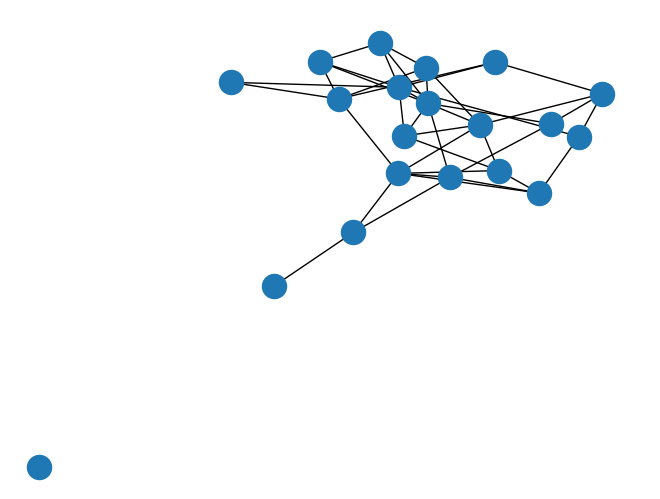

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

n = 20  # 10 nodes
m = 40  # 20 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

G = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(G):
    print(f"{v} {nx.degree(G, v)} {nx.clustering(G, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(G):
    print(line)

pos = nx.spring_layout(G, seed=seed)  # Seed for reproducible layout
nx.draw(G, pos=pos)
plt.show()

In [4]:
def coloring_conflicts (G, coloring):
    conflicts = 0
    # Use the edge set to check for conflicts
    for u, v in G.edges():
        # print(f"edge ({u}, {v}) has colors {coloring[u]} and {coloring[v]}")
        if coloring[u] == coloring[v]:
            conflicts += 1
    return conflicts

## Testing out coloring using built in greedy algorithm

In [5]:
def graph_coloring(G):
    # Use a greedy coloring algorithm
    coloring = nx.coloring.greedy_color(G, strategy='largest_first')
    return coloring

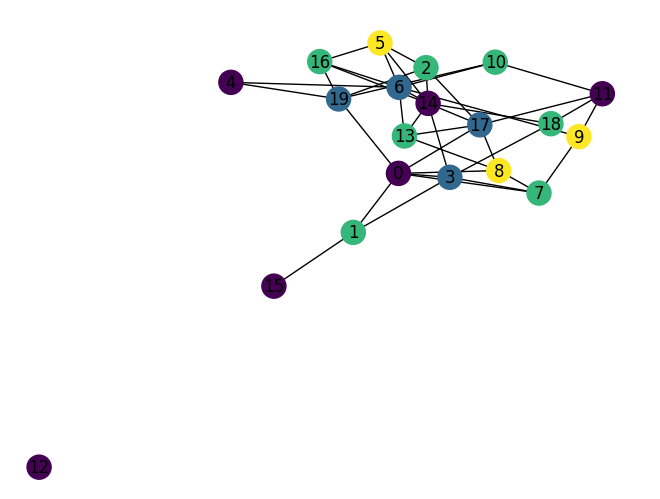

In [6]:
coloring = graph_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show() 

### Check for conflicts

In [7]:
conflicts = coloring_conflicts(G, coloring)
conflicts

0

## Randomly assigning colors

In [8]:

import random
      
def random_coloring(G):
    coloring = {}
    for node in G.nodes():
        coloring[node] = random.randint(0, n-1)  # Random color from 0 to n-1
    return coloring

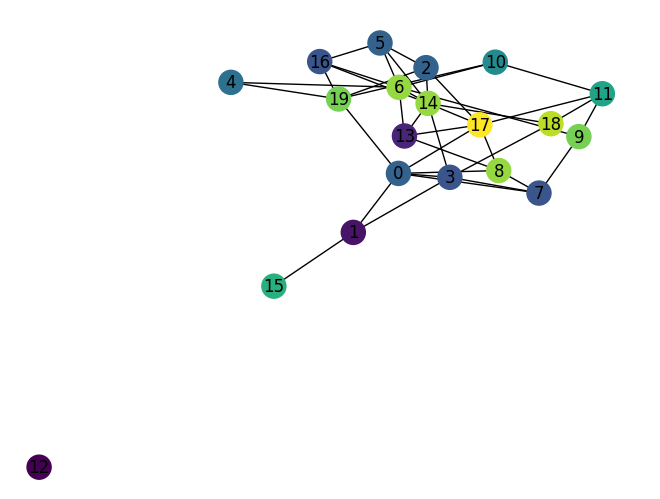

In [9]:
coloring = random_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

In [10]:
conflicts = coloring_conflicts(G, coloring)
print(f"Number of conflicts: {conflicts}")

Number of conflicts: 3


Trial 1: Number of conflicts: 1
Trial 2: Number of conflicts: 3
Trial 3: Number of conflicts: 5
Trial 4: Number of conflicts: 4
Trial 5: Number of conflicts: 2
Trial 6: Number of conflicts: 3
Trial 7: Number of conflicts: 2
Trial 8: Number of conflicts: 2
Trial 9: Number of conflicts: 1
Trial 10: Number of conflicts: 1
Trial 11: Number of conflicts: 2
Trial 12: Number of conflicts: 1
Trial 13: Number of conflicts: 4
Trial 14: Number of conflicts: 6
Trial 15: Number of conflicts: 6
Trial 16: Number of conflicts: 1
Trial 17: Number of conflicts: 2
Trial 18: Number of conflicts: 2
Trial 19: Number of conflicts: 2
Trial 20: Number of conflicts: 5
Trial 21: Number of conflicts: 2
Trial 22: Number of conflicts: 0
Trial 23: Number of conflicts: 3
Trial 24: Number of conflicts: 0
Trial 25: Number of conflicts: 0
Trial 26: Number of conflicts: 4
Trial 27: Number of conflicts: 1
Trial 28: Number of conflicts: 0
Trial 29: Number of conflicts: 0
Trial 30: Number of conflicts: 2
Trial 31: Number of

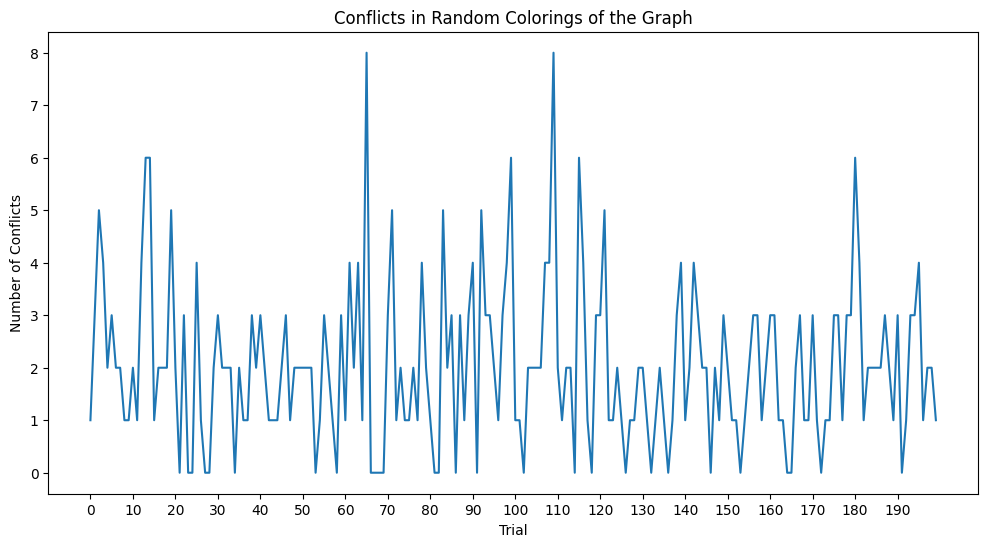

Average conflicts: 2.02


In [12]:
import numpy as np

list_of_conflicts = []
for i in range(200):
    multiple_coloring = random_coloring(G)
    node_colors = [coloring[node] for node in G.nodes()]
    conflicts = coloring_conflicts(G, multiple_coloring)
    list_of_conflicts.append(conflicts)
    print(f"Trial {i+1}: Number of conflicts: {conflicts}")


plt.figure(figsize=(12, 6))
plt.plot(list_of_conflicts)
plt.xlabel('Trial')
plt.ylabel('Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(range(0, 200, 10))

plt.show()

print(f"Average conflicts: {np.mean(list_of_conflicts):.2f}")


An average number of conflicts of 1.55 / 30 possible is really good odds for a random assignment of colors

For 100 trials : Average Number of conflicts: 2.03
For 200 trials : Average Number of conflicts: 1.92
For 300 trials : Average Number of conflicts: 1.94
For 400 trials : Average Number of conflicts: 1.94
For 500 trials : Average Number of conflicts: 2.05
For 600 trials : Average Number of conflicts: 2.01
For 700 trials : Average Number of conflicts: 2.02
For 800 trials : Average Number of conflicts: 1.97
For 900 trials : Average Number of conflicts: 2.03
For 1000 trials : Average Number of conflicts: 2.00


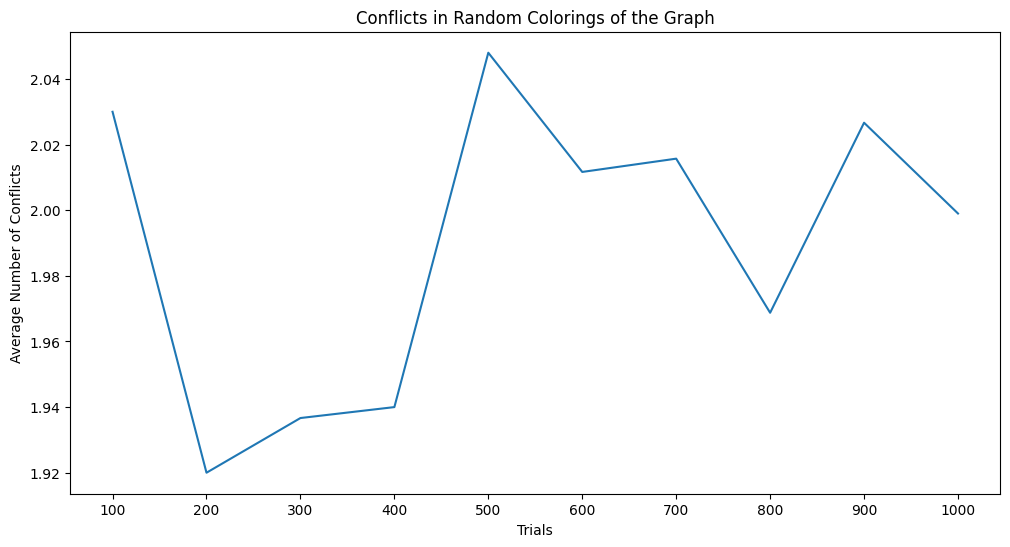

In [13]:
average_conflicts = []
trials = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
for i in range(len(trials)):
    list_of_conflicts = []
    for j in range(trials[i]):
        multiple_coloring = random_coloring(G)
        node_colors = [coloring[node] for node in G.nodes()]
        conflicts = coloring_conflicts(G, multiple_coloring)
        list_of_conflicts.append(conflicts)
    average_conflicts.append(np.mean(list_of_conflicts))
    print(f"For {trials[i]} trials : Average Number of conflicts: {average_conflicts[-1]:.2f}")


plt.figure(figsize=(12, 6))
plt.plot(trials, average_conflicts)
plt.xlabel('Trials')
plt.ylabel('Average Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(trials)

plt.show()


## Step 1 Assignment

node degree clustering
0 7 0.14285714285714285
1 2 0
2 0 0
3 3 0.3333333333333333
4 5 0.1
5 5 0.3
6 3 0
7 7 0.2857142857142857
8 6 0.26666666666666666
9 4 0.5
10 5 0.2
11 5 0.3
12 5 0.2
13 3 0
14 6 0.2
15 3 0.3333333333333333
16 2 0
17 5 0.4
18 2 0
19 2 0

the adjacency list
0 8 3 10 7 18 6 15
1 4 5
2
3 11 7
4 6 8 14 13
5 17 14 7 11
6 19
7 14 17 8 13
8 14 17 16
9 12 10 17 11
10 12 14 15
11 12 17
12 16 18
13 15
14 19
15
16
17
18
19


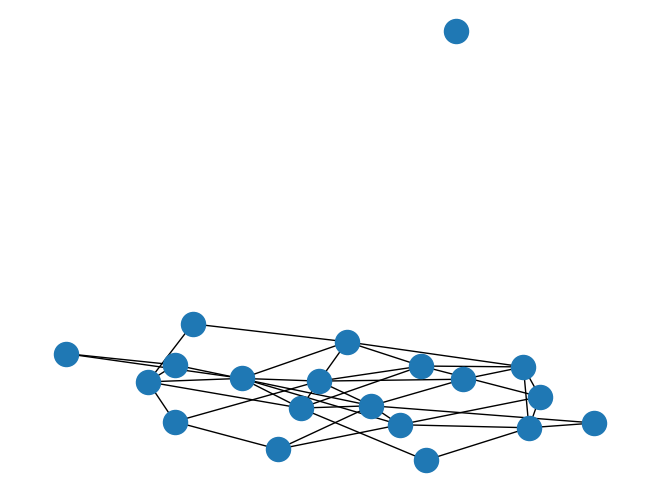

In [15]:
n = 20  # 10 nodes
m = 40  # 20 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

T = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(T):
    print(f"{v} {nx.degree(T, v)} {nx.clustering(T, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(T):
    print(line)

pos = nx.spring_layout(T, seed=seed)  # Seed for reproducible layout
nx.draw(T, pos=pos)
plt.show()

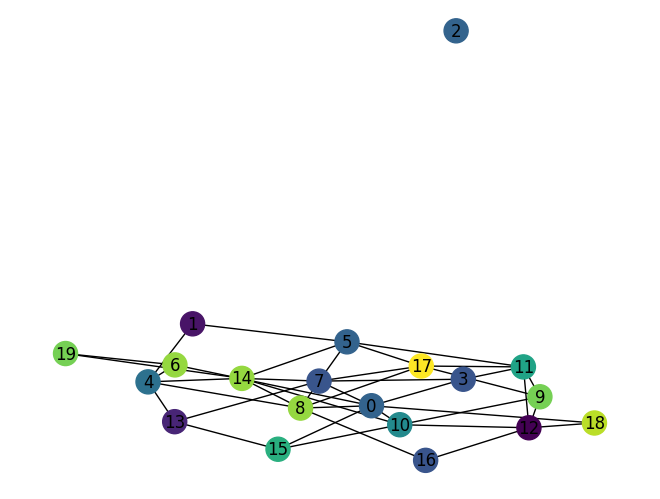

In [17]:
for i in range(200):
    multiple_coloring = random_coloring(T)
    node_colors = [coloring[node] for node in T.nodes()]
    conflicts = coloring_conflicts(T, multiple_coloring)
    list_of_conflicts.append(conflicts)

nx.draw(T, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

In [ ]:
def chromatic_optimiser(T) :
    

